In [13]:
# =============================================================================
# Quins errors fan a la ZONA DE FLUIDESA? Les 5 mateixes multiplicacions
# =============================================================================
# PREGUNTA: els mateixos histogrames que error_types.ipynb (A998), pero amb les
# dades de la zona de Fluidesa, per veure els errors sense l'artefacte de
# correccio de l'A998.
#
# PER QUE AQUI NOMES CAL UN HISTOGRAMA PER INTENT ---------------------------
# A l'A998 els histogrames van partits en dos perque l'app corregeix tecla a
# tecla: si la primera xifra ja fa impossible el producte, la resposta s'envia
# sola i queda registrada a mitges (Decisio #11). La zona de Fluidesa es una app
# diferent -- cartes tipus Leitner, dos intents per carta, sense temporitzador --
# i NO es comporta aixi. Les tres proves es tornen a passar a la cel.la seguent
# sobre dades vives, pero els numeros son:
#   . de les respostes errronies d'UNA xifra a productes de dues, el 63,9% SON
#     la desena correcta (sobre tots els fets; sobre nomes aquests 5 i el 1r
#     intent surt ~48%). A l'A998 era l'1,06% (un forat de ~16x). Aqui no
#     s'envia res fins que l'alumne envia, aixi que la xifra que ha teclejat
#     primer es exactament la que queda registrada.
#   . mediana de durada: 4,93 s un 1r intent correcte i 10,02 s un d'erroni. Els
#     errors son MES LENTS que els encerts, al contrari de l'A998 (4,20 s els
#     encerts contra 1,40-1,63 s els errors, o sigui rebuig immediat).
#   . no hi ha el bloc 66/67/76/77 (Decisio #12): les respostes errronies mes
#     frequents als 5 fets son 54, 56, 42, 24, 45, 64, 46, 36 -- totes
#     aritmetiques, totes entre 7,6 i 10 s. Cap poblacio de tecleig a separar.
# Per tant: totes les respostes numeriques van al MATEIX eix, i no cal cap flag
# de sittings de velocitat.
#
# ELS DOS HISTOGRAMES SON PER INTENT, NO PER NOMBRE DE XIFRES ---------------
#   FIG A  1r intent: la resposta espontania (tota carta que no es 'Correct at
#          first'). Color = si despres la va recuperar al 2n intent.
#   FIG B  2n intent: nomes cartes que van acabar 'Incorrect'. Si la carta va
#          acabar 'Correct at second' el 2n intent era bo i no es una resposta
#          errronia -- per construccio, aqui tot es "ha fallat els dos".
#
# QUINS 5 FETS: els mateixos que l'A998 (4x8, 5x8, 6x8, 7x8, 8x8), perque la
# gracia es comparar la MATEIXA operacio entre les dues apps. On son de veritat
# dins de Fluidesa ho diuen les columnes fluency_rank / fluency_error_pct, que
# es calculen sobre TOTS els fets: 6x8 es el 5e (39,6%), 7x8 el 6e (39,3%), 8x8
# el 7e (39,3%), pero 4x8 el 13e (30,8%) i 5x8 el 29e (19,3%).
# ATENCIO: Fluidesa tambe treballa les taules 10, 11 i 12, que l'A998 no te, i
# aquestes dominen la seva dificultat (12x12 62,5%, 11x11 59,7%, 11x12 58,0%).
# Res d'aqui diu que aquests 5 siguin els fets mes dificils de Fluidesa.
#
# DECISIONS APLICADES (Learning_Team_Plots/Decisions.txt):
#   #1 Fluidesa com a zona de comparacio  .  #2 edats 8-15 per
#   classroom_course_age (a la practica aquesta app nomes te 8-11)  .  #3 la
#   query queda com a .sql i aqui s'imprimeix com s'han obtingut les dades  .
#   #5 nomes multiplicacions  .  #8 nomes ES_2025
# La #7 (descartar el primer statement) NO aplica: aqui no hi ha packs amb
# compte enrere, aixi que no hi ha un primer item no representatiu a treure.
#
# CAVEAT DE COMPARABILITAT AMB L'A998: no son la mateixa prova ni la mateixa
# poblacio d'intents. L'A998 es un test cronometrat de 120 s amb una resposta
# per item; Fluidesa es practica espaiada amb dos intents per carta i sense
# rellotge. Les taxes d'error no son comparables en nivell; el que es compara es
# QUINES respostes donen quan s'equivoquen.
# =============================================================================
import re
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- parametres -------------------------------------------------------------
YEARS = ["ES_2025"]                                    # Decisio #8   {YEARS}
FACTS = [(4, 8), (5, 8), (6, 8), (7, 8), (8, 8)]       # els de l'A998  {FACTS}
AGE_MIN, AGE_MAX = 8, 15                               # Decisio #2   {AGES}
# Minim de respostes numeriques per pintar un panell: amb ~100 valors possibles
# i n petita, l'histograma es soroll.
MIN_CELL_ERRORS = 300
ANNOT_TOP_N = 12          # quants pics s'etiqueten per panell
ANNOT_FLOOR_PCT = 1.0

HERE = Path.cwd()          # descriptive/ or mechanistic/ (run the notebook from its own folder)
ROOT = HERE
while not (ROOT / "databricks_connector.py").exists():
    if ROOT == ROOT.parent:
        raise FileNotFoundError("databricks_connector.py not found in any parent directory")
    ROOT = ROOT.parent      # repo root -- holds databricks_connector.py and cached_query.py
sys.path.insert(0, str(ROOT))
(HERE / "cache").mkdir(exist_ok=True)
(HERE / "plots").mkdir(exist_ok=True)

from databricks_connector import query   # kept: PROVA 2 below is a live self-check, never cached
from cached_query import cached_query

SQL_PATH = HERE / "queries" / "fluency_hardest_facts_error_answers.sql"
CACHE_DIR = HERE / "cache"

# El .sql porta els defaults escrits als marcadors, aixi que segueix sent
# executable sol. Si un marcador desapareixia, aixo peta -- millor petar que
# executar en silenci una poblacio diferent de la que diu el notebook.
sql_raw = SQL_PATH.read_text(encoding="utf-8")

years_sql = ", ".join(f"'{y}'" for y in YEARS)
sql_text, n_y = re.subn(r"IN \([^)]*\)(\s*-- \{YEARS\})", f"IN ({years_sql})\\1", sql_raw)
assert n_y == 1, f"Esperava 1 marcador -- {{YEARS}}, n'he trobat {n_y}"

facts_sql = ", ".join(f"({lo}, {hi})" for lo, hi in FACTS)
sql_text, n_f = re.subn(r"IN \([^\n]*\)(\s*-- \{FACTS\})", f"IN ({facts_sql})\\1", sql_text)
assert n_f == 1, f"Esperava 1 marcador -- {{FACTS}}, n'he trobat {n_f}"

sql_text, n_a = re.subn(r"BETWEEN \d+ AND \d+(\s*-- \{AGES\})",
                        f"BETWEEN {AGE_MIN} AND {AGE_MAX}\\1", sql_text)
assert n_a == 1, f"Esperava 1 marcador -- {{AGES}}, n'he trobat {n_a}"

err = cached_query(SQL_PATH, CACHE_DIR, sql_text=sql_text)

facts = (err.groupby(["lo", "hi", "product"], as_index=False)
            .agg(fluency_rank=("fluency_rank", "max"),
                 fluency_error_pct=("fluency_error_pct", "max"),
                 n_fact=("n_fact_all_ages", "max"))
            .astype({"lo": int, "hi": int, "product": int, "fluency_rank": int})
            .sort_values("fluency_error_pct", ascending=False))

print("FLUIDESA | tipus d'error a les 5 operacions mes dificils de l'A998")
print(f"YEARS = {YEARS} | FACTS = {FACTS} | edats {AGE_MIN}-{AGE_MAX}")
print("Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts")
print("      JOIN dwh_global_dimensions_historic.d_students per student_uuid")
print("      (aqui NO per unique_id, al contrari que a les taules de l'A998),")
print("      nomes operation_type = 'multiplication'.")
print("Parelles commutatives fusionades: lo = min, hi = max.")
print(f"Files: {len(err):,} (fet x curs x intent x resposta) | cache -> {CACHE_DIR.relative_to(ROOT)}/")
print("\nOn son aquests 5 fets dins de la dificultat de FLUIDESA (tots els fets,")
print("taules fins al 12 incloses):")
print(facts.assign(operacio=lambda d: d.lo.astype(str) + "×" + d.hi.astype(str)
                                      + " = " + d["product"].astype(str))
           [["operacio", "fluency_rank", "fluency_error_pct", "n_fact"]]
           .to_string(index=False))
print(f"\nEdats presents: {sorted(int(a) for a in err['classroom_course_age'].unique())}")
print(f"Respostes errronies cobertes: {err['n'].sum():,}"
      f" ({err.loc[err.attempt_no == 1, 'n'].sum():,} del 1r intent,"
      f" {err.loc[err.attempt_no == 2, 'n'].sum():,} del 2n)")

FLUIDESA | tipus d'error a les 5 operacions mes dificils de l'A998
YEARS = ['ES_2025'] | FACTS = [(4, 8), (5, 8), (6, 8), (7, 8), (8, 8)] | edats 8-15
Font: bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts
      JOIN dwh_global_dimensions_historic.d_students per student_uuid
      (aqui NO per unique_id, al contrari que a les taules de l'A998),
      nomes operation_type = 'multiplication'.
Parelles commutatives fusionades: lo = min, hi = max.
Files: 21,843 (fet x curs x intent x resposta) | cache -> descriptive\cache/

On son aquests 5 fets dins de la dificultat de FLUIDESA (tots els fets,
taules fins al 12 incloses):
operacio  fluency_rank  fluency_error_pct  n_fact
6×8 = 48             5             39.552  576075
7×8 = 56             6             39.281  522310
8×8 = 64             7             39.265  281313
4×8 = 32            13             30.779  579515
5×8 = 40            29             19.261  466554

Edats presents: [8, 9, 10, 11, 12, 14]
Respostes errronie

In [14]:
# --- les tres proves de que aqui NO hi ha l'artefacte de l'A998 -------------
# No es dona per bo el que diu la capcalera: es torna a mesurar. Els numeros de
# l'A998 son els de la Decisio #11, mesurats el 2026-07-30.
A998_PCT_1XIFRA_ES_DESENA = 1.06
A998_MED_CORRECTE, A998_MED_ERROR = 4.20, 1.40

# PROVA 1. De les respostes d'una xifra a productes de dues, quantes son la
# desena correcta? Si l'app enviava la resposta a la primera tecla dolenta,
# aquesta xifra no hi podria ser (l'alumne encara anava be i el sistema el
# deixava continuar), i per tant seria ~0.
# Nomes 1r intent, per comparar amb el mateix objecte que a l'A998 (una resposta
# per item). Al 2n intent la xifra ja no es "la primera que se li acut".
fd = err[(err["error_type"] == "fewer_digits") & (err["attempt_no"] == 1)]
pct_desena = 100 * fd.loc[fd["user_answer"] == fd["product"] // 10, "n"].sum() / fd["n"].sum()
print("PROVA 1 -- respostes d'UNA xifra que son la desena correcta del producte")
print(f"  Fluidesa: {pct_desena:.1f}%   |   A998: {A998_PCT_1XIFRA_ES_DESENA}%")
print("  (1r intent, nomes els 5 fets. Sobre TOTS els fets de Fluidesa es 63,9%;")
print("  el que importa es l'ordre de magnitud contra l'1,06% de l'A998.)")
print("  A l'A998 la desena correcta era el forat de la distribucio; aqui n'es")
print("  el mode. Son dos mecanismes oposats, no una diferencia de grau.")
assert pct_desena > 25, "PROVA 1 falla: aixo s'assembla a l'artefacte de l'A998"

# PROVA 2. Durada dels encerts contra la dels errors. Cal una consulta a part:
# el .sql nomes torna respostes errronies, no els encerts.
dur = query(f"""
SELECT a.attempt_result AS res, COUNT(*) AS n,
       CAST(ROUND(PERCENTILE(a.first_attempt_duration, 0.5), 2) AS DOUBLE) AS med_1r
FROM bi_gold_prod.dwh_digital_practice.f_elementary_fluency_attempts a
INNER JOIN bi_gold_prod.dwh_global_dimensions_historic.d_students s
        ON s.student_uuid = a.student_uuid AND s.academic_year_id = a.academic_year_id
WHERE a.academic_year_id IN ({', '.join(f"'{y}'" for y in YEARS)})
  AND a.operation_type = 'multiplication'
  AND s.classroom_course_age BETWEEN {AGE_MIN} AND {AGE_MAX}
  AND (LEAST(CAST(TRIM(SPLIT(a.operation, 'X')[0]) AS INT),
             CAST(TRIM(SPLIT(a.operation, 'X')[1]) AS INT)),
       GREATEST(CAST(TRIM(SPLIT(a.operation, 'X')[0]) AS INT),
                CAST(TRIM(SPLIT(a.operation, 'X')[1]) AS INT)))
      IN ({', '.join(f'({lo}, {hi})' for lo, hi in FACTS)})
GROUP BY a.attempt_result ORDER BY n DESC
""")
print("\nPROVA 2 -- durada del 1r intent, encerts contra errors")
print(dur.to_string(index=False))
med_ok = float(dur.loc[dur["res"] == "Correct at first", "med_1r"].iloc[0])
med_ko = float(dur.loc[dur["res"] == "Incorrect", "med_1r"].iloc[0])
print(f"  Fluidesa: {med_ok:.2f} s encert vs {med_ko:.2f} s error  ->  els errors"
      " son MES LENTS")
print(f"  A998:     {A998_MED_CORRECTE} s encert vs {A998_MED_ERROR} s error  ->"
      " els errors eren 3x MES RAPIDS (rebuig immediat)")
assert med_ko > med_ok, "PROVA 2 falla: els errors son mes rapids, com a l'A998"

# PROVA 3. Hi ha un bloc de valors que surti igual a tots els fets? A l'A998,
# 66/67/76/77 eren fins al 26% de les respostes de dues xifres, identics a fets
# amb productes diferents. Aqui es mira quins valors surten a TOTS 5 i quant
# pesen.
top = (err[err["attempt_no"] == 1]
       .groupby("user_answer", dropna=True)
       .agg(n=("n", "sum"), n_fets=("product", "nunique"),
            med_dur=("median_duration", "median"))
       .nlargest(12, "n"))
print("\nPROVA 3 -- les 12 respostes errronies mes frequents del 1r intent")
print(top.round(2).to_string())
mash = [v for v in (66, 67, 76, 77) if v in top.index]
print(f"  Valors del bloc de l'A998 que apareixen aqui al top 12: {mash or 'cap'}")
print("  Les durades son totes semblants (~8-10 s): una sola poblacio, no dues.")

# --- grups i caselles ------------------------------------------------------
# Fora de l'histograma, per motius diferents i tots comptats a les taules:
#   no_answer        no hi ha valor (39% dels 1rs intents errats!). Sense
#                    posicio a un eix numeric.
#   too_many_digits  mes xifres que el producte, i son quasi totes la resposta
#                    bona amb una tecla de mes (400 per 40, 322 per 32).
#   equals_product   marcat com a erroni pero la resposta es la bona.
# `fewer_digits` SI que entra: aqui es una resposta de veritat (la desena), no
# un registre tallat pel sistema com a l'A998.
NOT_PLOTTED = ["no_answer", "too_many_digits", "equals_product"]
plot = err[~err["error_type"].isin(NOT_PLOTTED)].copy()
assert (plot["user_answer"] != plot["product"]).all(), \
    "Hi ha barres justament al producte correcte"
assert plot["user_answer"].between(0, 99).all(), "Hi ha respostes fora de 0-99"

cell = plot.groupby(["lo", "hi", "classroom_course_age", "attempt_no"])["n"].sum()
print("\nRespostes numeriques per casella (1r intent | 2n intent):")
t = cell.reset_index()
t["operacio"] = t["lo"].astype(str) + "×" + t["hi"].astype(str)
print(t.pivot_table(index="operacio", columns=["attempt_no", "classroom_course_age"],
                    values="n", aggfunc="sum").to_string())

first = cell.xs(1, level="attempt_no")
AGES = sorted(int(a) for a in plot["classroom_course_age"].unique()
              if (first.xs(a, level="classroom_course_age") >= MIN_CELL_ERRORS).all())
print(f"\nCursos que es pinten: {AGES}")
print(f"Cursos exclosos: {sorted({int(a) for a in plot['classroom_course_age']} - set(AGES))}"
      " -- aquesta app es de primaria, a partir de 12 anys quasi no te dades.")

print("\nRepartiment per tipus i intent (% de la columna):")
by_att = err.pivot_table(index="error_type", columns="attempt_no", values="n",
                         aggfunc="sum", fill_value=0)
print((100 * by_att / by_att.sum()).round(2).to_string())

PROVA 1 -- respostes d'UNA xifra que son la desena correcta del producte
  Fluidesa: 56.0%   |   A998: 1.06%
  (1r intent, nomes els 5 fets. Sobre TOTS els fets de Fluidesa es 63,9%;
  el que importa es l'ordre de magnitud contra l'1,06% de l'A998.)
  A l'A998 la desena correcta era el forat de la distribucio; aqui n'es
  el mode. Son dos mecanismes oposats, no una diferencia de grau.

PROVA 2 -- durada del 1r intent, encerts contra errors
              res       n  med_1r
 Correct at first 1614060    6.57
Correct at second  473117   10.03
        Incorrect  338590   10.35
  Fluidesa: 6.57 s encert vs 10.35 s error  ->  els errors son MES LENTS
  A998:     4.2 s encert vs 1.4 s error  -> els errors eren 3x MES RAPIDS (rebuig immediat)

PROVA 3 -- les 12 respostes errronies mes frequents del 1r intent
                 n  n_fets  med_dur
user_answer                        
54.0         29986       5     9.22
56.0         26303       4     8.50
42.0         22184       5     9.06
24.0    

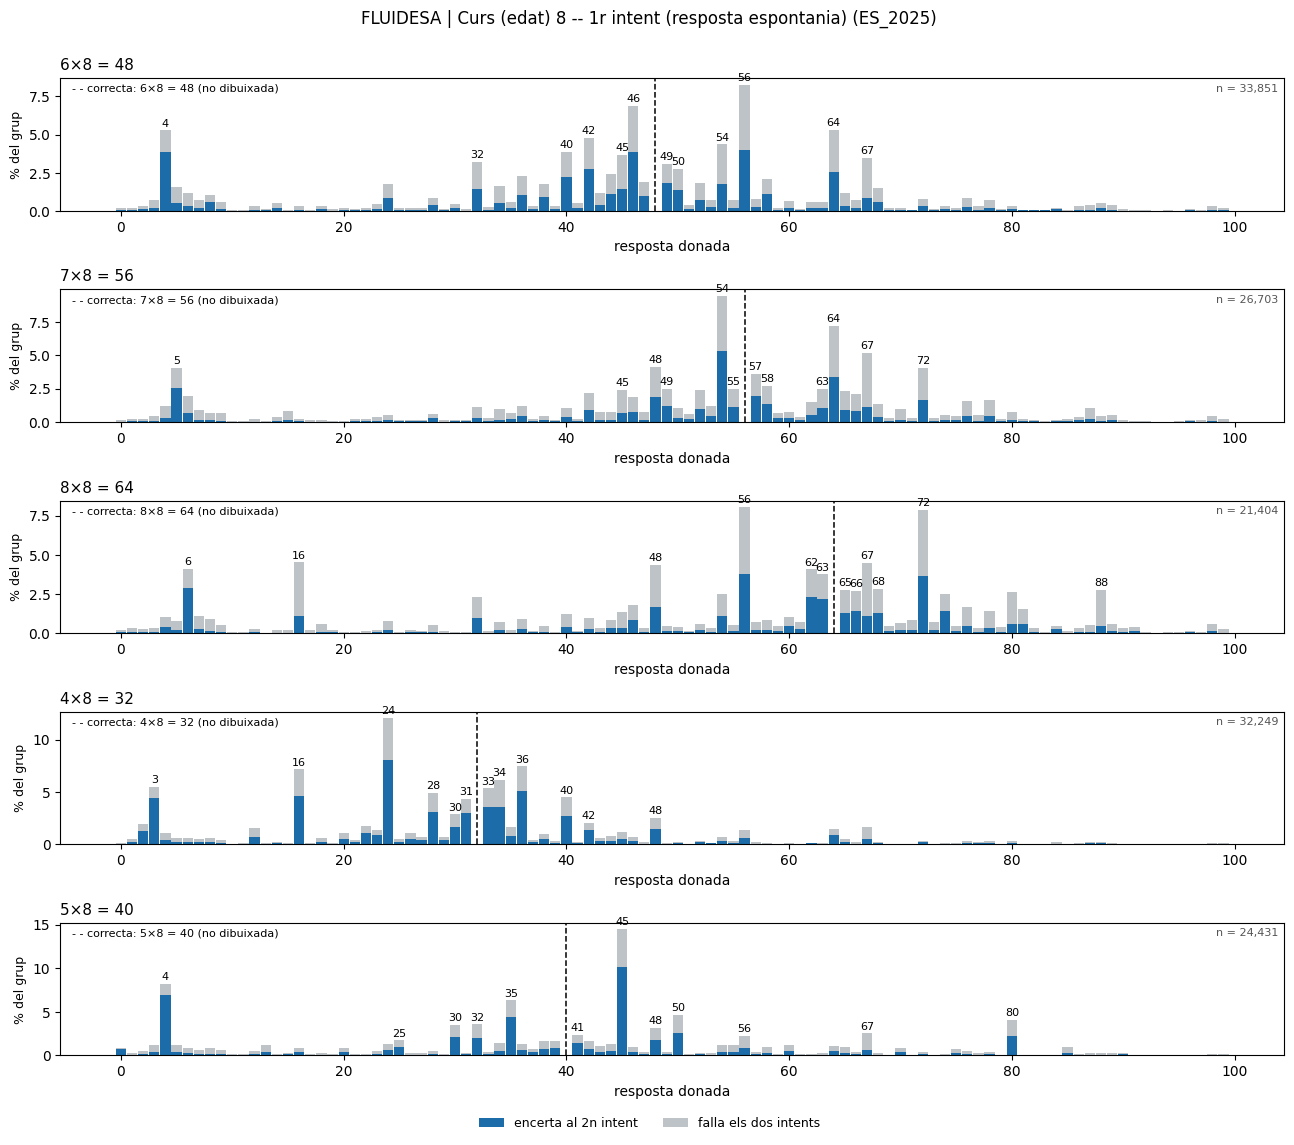

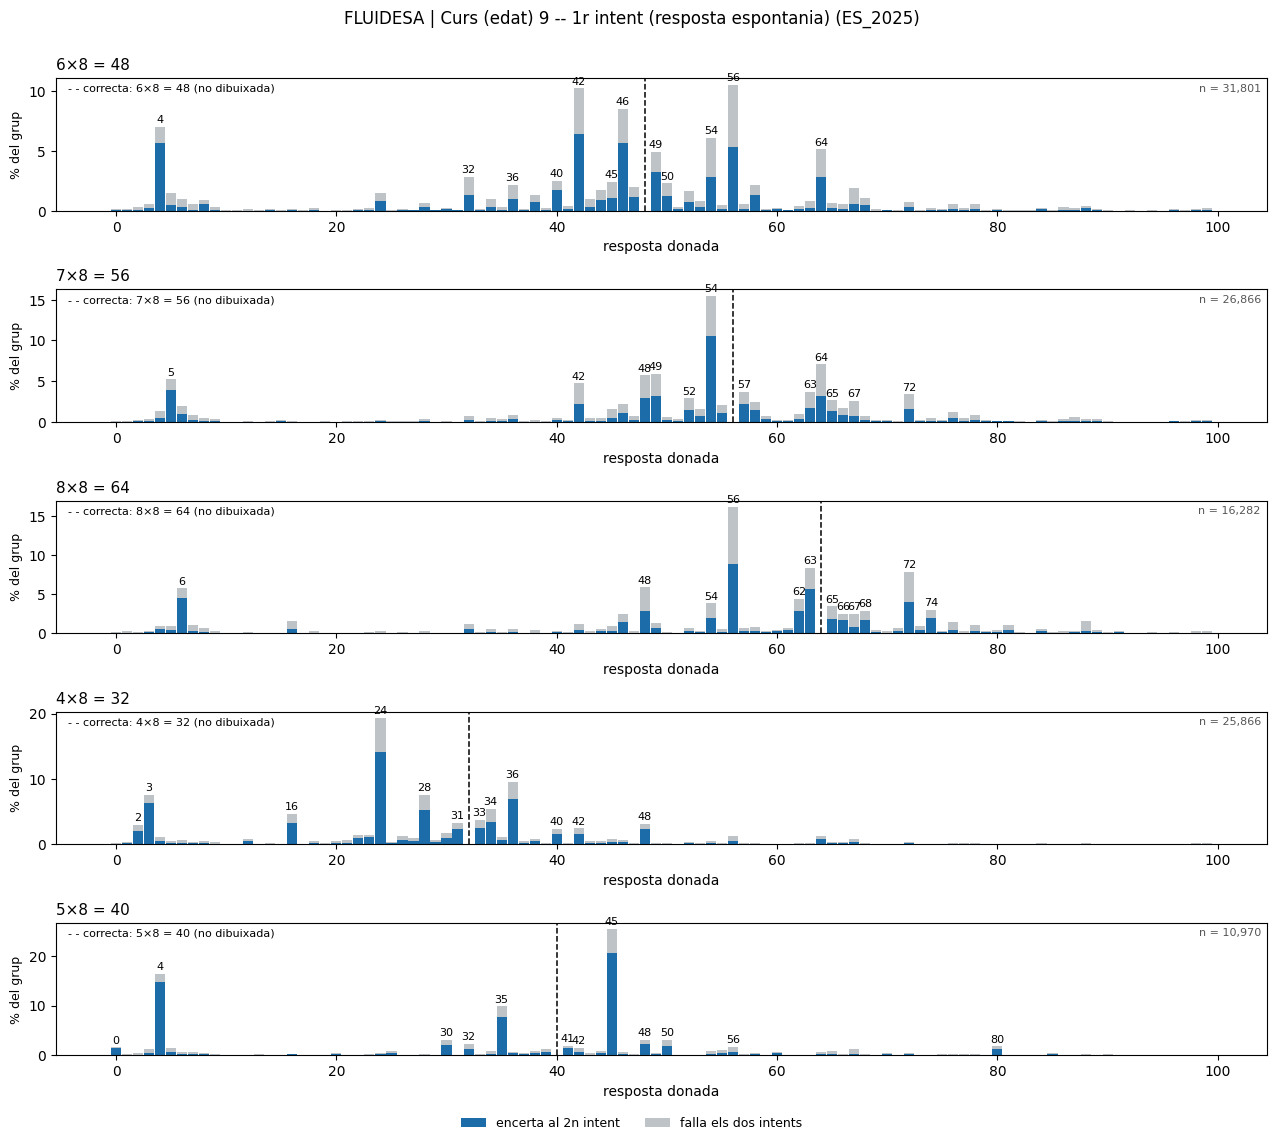

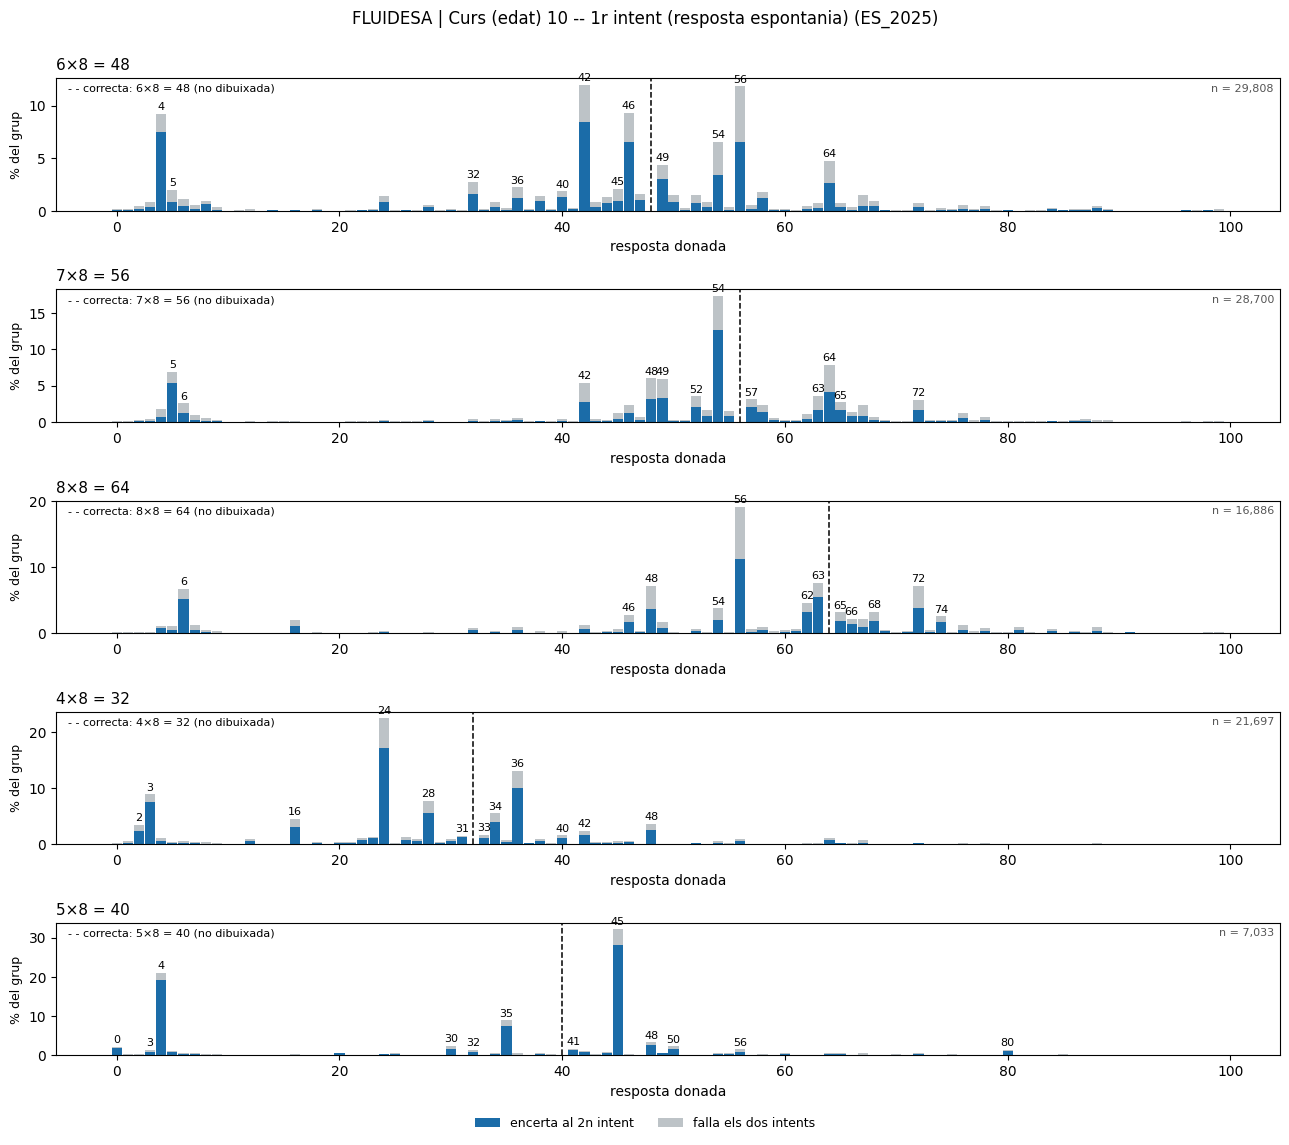

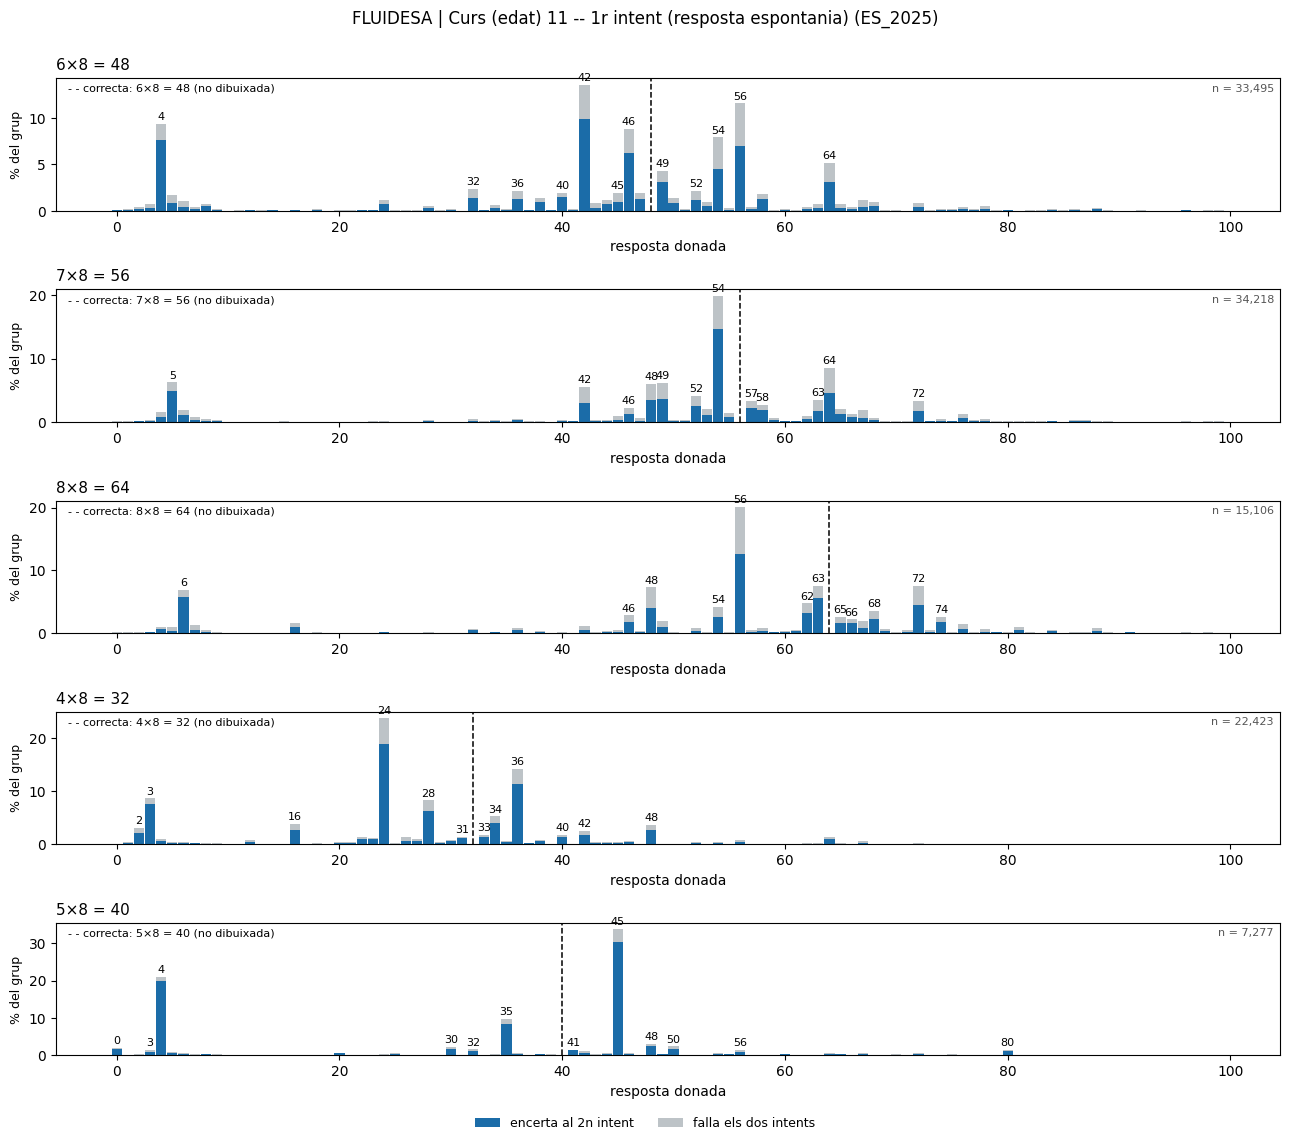

FIG A -> plots/fluency_hardest_errors_attempt1_ageNN.png / .pdf (4 figures)


In [ ]:
# --- FIG A: 1r intent -- la resposta espontania -----------------------------
# Una figura per curs, cinc panells (un per operacio), com la FIG 2 de l'A998.
# COLOR: si la carta va acabar be al 2n intent (blau) o va fallar els dos
# intents (gris). Es la divisio propia d'aquesta app i separa el llapsus del
# buit real: la mateixa resposta errronia vol dir coses diferents segons si
# l'alumne se'n surt tot seguit o no.
# La resposta correcta es marca amb la linia negra i NO es dibuixa.
COLOR_RECOVERED = "#1b6ca8"   # ha encertat al 2n intent
COLOR_FAILED = "#bdc3c7"      # ha fallat els dos


def plot_attempt(age, attempt_no, split_by_recovery=True):
    d_age = plot[(plot["classroom_course_age"] == age)
                 & (plot["attempt_no"] == attempt_no)]
    fig, axes = plt.subplots(len(facts), 1, figsize=(13, 2.3 * len(facts)),
                             squeeze=False)
    for i, f in enumerate(facts.itertuples()):
        ax = axes[i][0]
        d = d_age[(d_age["lo"] == f.lo) & (d_age["hi"] == f.hi)]
        tot = d["n"].sum()
        if split_by_recovery:
            rec = (d[d["recovered_at_second"] == 1].groupby("user_answer")["n"].sum()
                   .reindex(range(0, 100), fill_value=0))
            fai = (d[d["recovered_at_second"] == 0].groupby("user_answer")["n"].sum()
                   .reindex(range(0, 100), fill_value=0))
            ax.bar(rec.index, 100 * rec / tot, width=0.92, color=COLOR_RECOVERED)
            ax.bar(fai.index, 100 * fai / tot, width=0.92, color=COLOR_FAILED,
                   bottom=100 * rec / tot)
            height = 100 * (rec + fai) / tot
        else:
            s = (d.groupby("user_answer")["n"].sum()
                  .reindex(range(0, 100), fill_value=0))
            ax.bar(s.index, 100 * s / tot, width=0.92, color=COLOR_FAILED)
            height = 100 * s / tot

        ax.axvline(f.product, color="black", ls="--", lw=1.1)
        peaks = height[height >= ANNOT_FLOOR_PCT].nlargest(ANNOT_TOP_N)
        for x, y in peaks.items():
            ax.annotate(f"{int(x)}", xy=(x, y), xytext=(0, 1.5),
                        textcoords="offset points", ha="center", va="bottom",
                        fontsize=8)

        ax.set_title(f"{f.lo}×{f.hi} = {f.product}", fontsize=11, loc="left")
        ax.set_ylabel("% del grup", fontsize=9)
        ax.set_xlabel("resposta donada")
        ax.tick_params(labelbottom=True)
        ax.annotate(f"- - correcta: {f.lo}×{f.hi} = {f.product} (no dibuixada)",
                    xy=(0.01, 0.96), xycoords="axes fraction",
                    ha="left", va="top", fontsize=8)
        ax.annotate(f"n = {int(tot):,}", xy=(0.995, 0.96), xycoords="axes fraction",
                    ha="right", va="top", fontsize=8, color="#555555")

    if split_by_recovery:
        fig.legend(handles=[Patch(facecolor=COLOR_RECOVERED, label="encerta al 2n intent"),
                            Patch(facecolor=COLOR_FAILED, label="falla els dos intents")],
                   loc="lower center", ncol=2, frameon=False, fontsize=9,
                   bbox_to_anchor=(0.5, -0.004))
    label = "1r intent (resposta espontania)" if attempt_no == 1 \
            else "2n intent (nomes cartes que van fallar les dues vegades)"
    fig.suptitle(f"FLUIDESA | Curs (edat) {age} -- {label} (ES_2025)", fontsize=12)
    fig.tight_layout(rect=(0, 0.02, 1, 0.98))
    out = HERE / "plots" / f"fluency_hardest_errors_attempt{attempt_no}_age{age:02d}"
    fig.savefig(out.with_suffix(".png"), dpi=110, bbox_inches="tight")
    fig.savefig(out.with_suffix(".pdf"), bbox_inches="tight")
    plt.show()

for age in AGES:
    plot_attempt(age, 1, split_by_recovery=True)
print(f"FIG A -> plots/fluency_hardest_errors_attempt1_ageNN.png / .pdf ({len(AGES)} figures)")

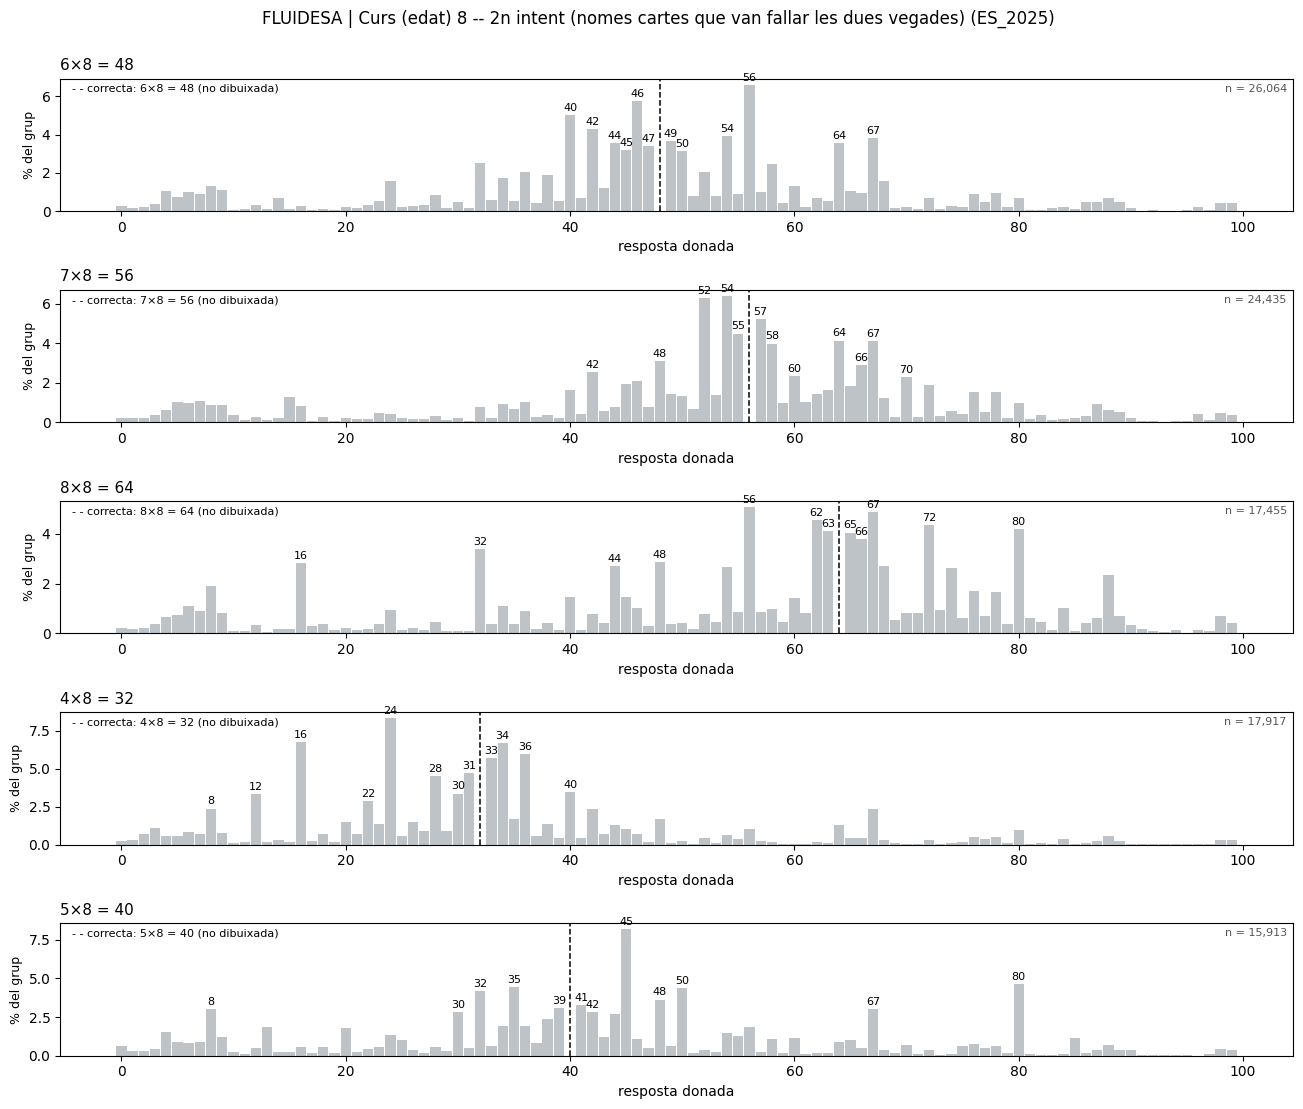

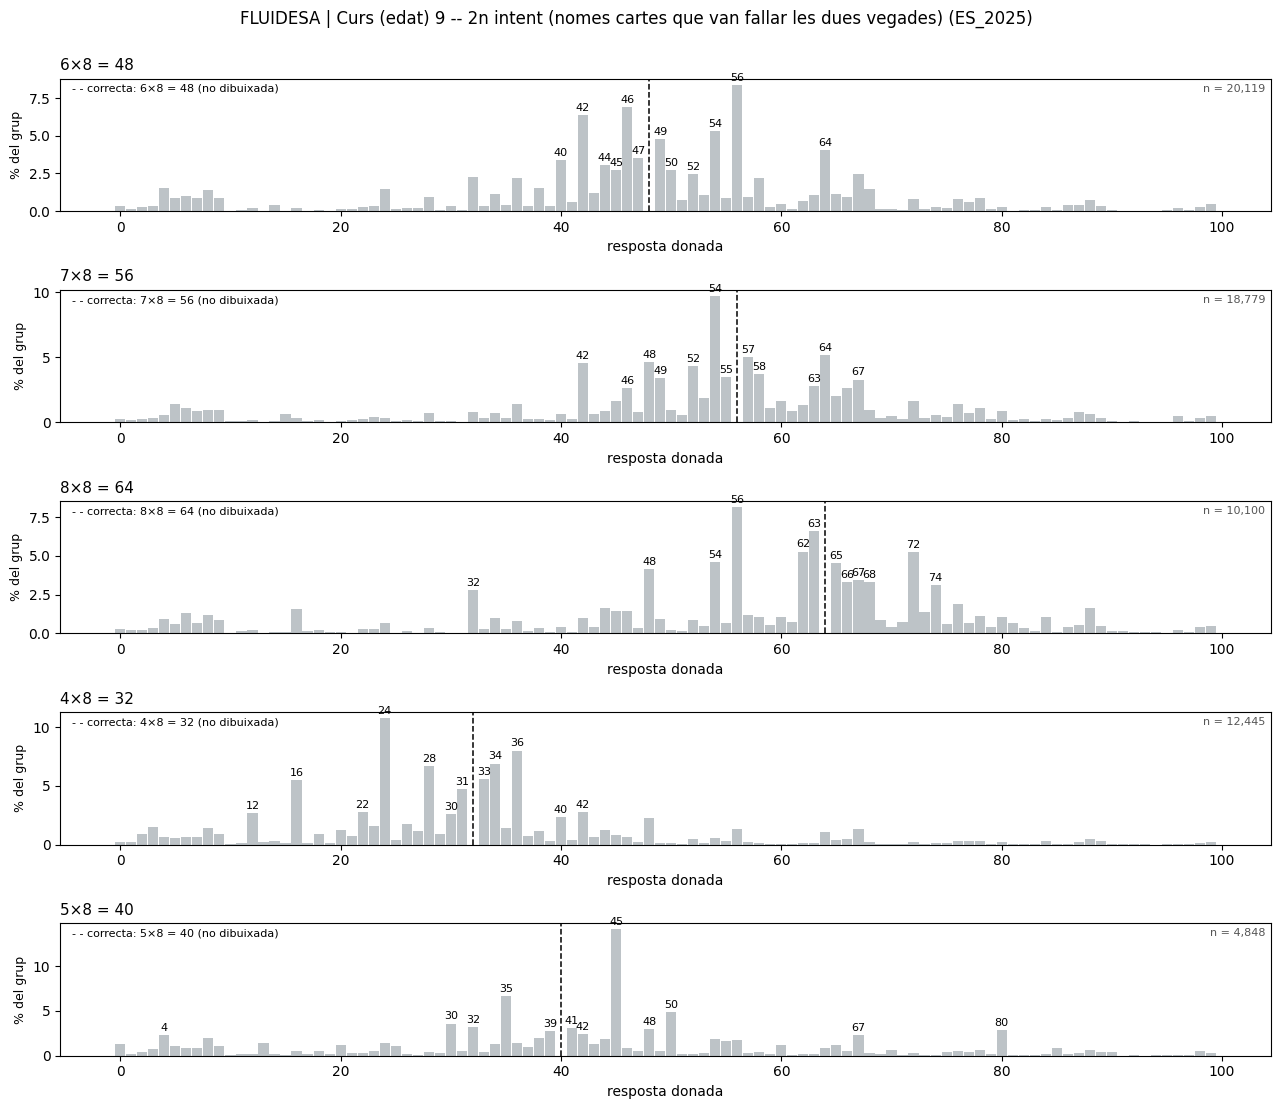

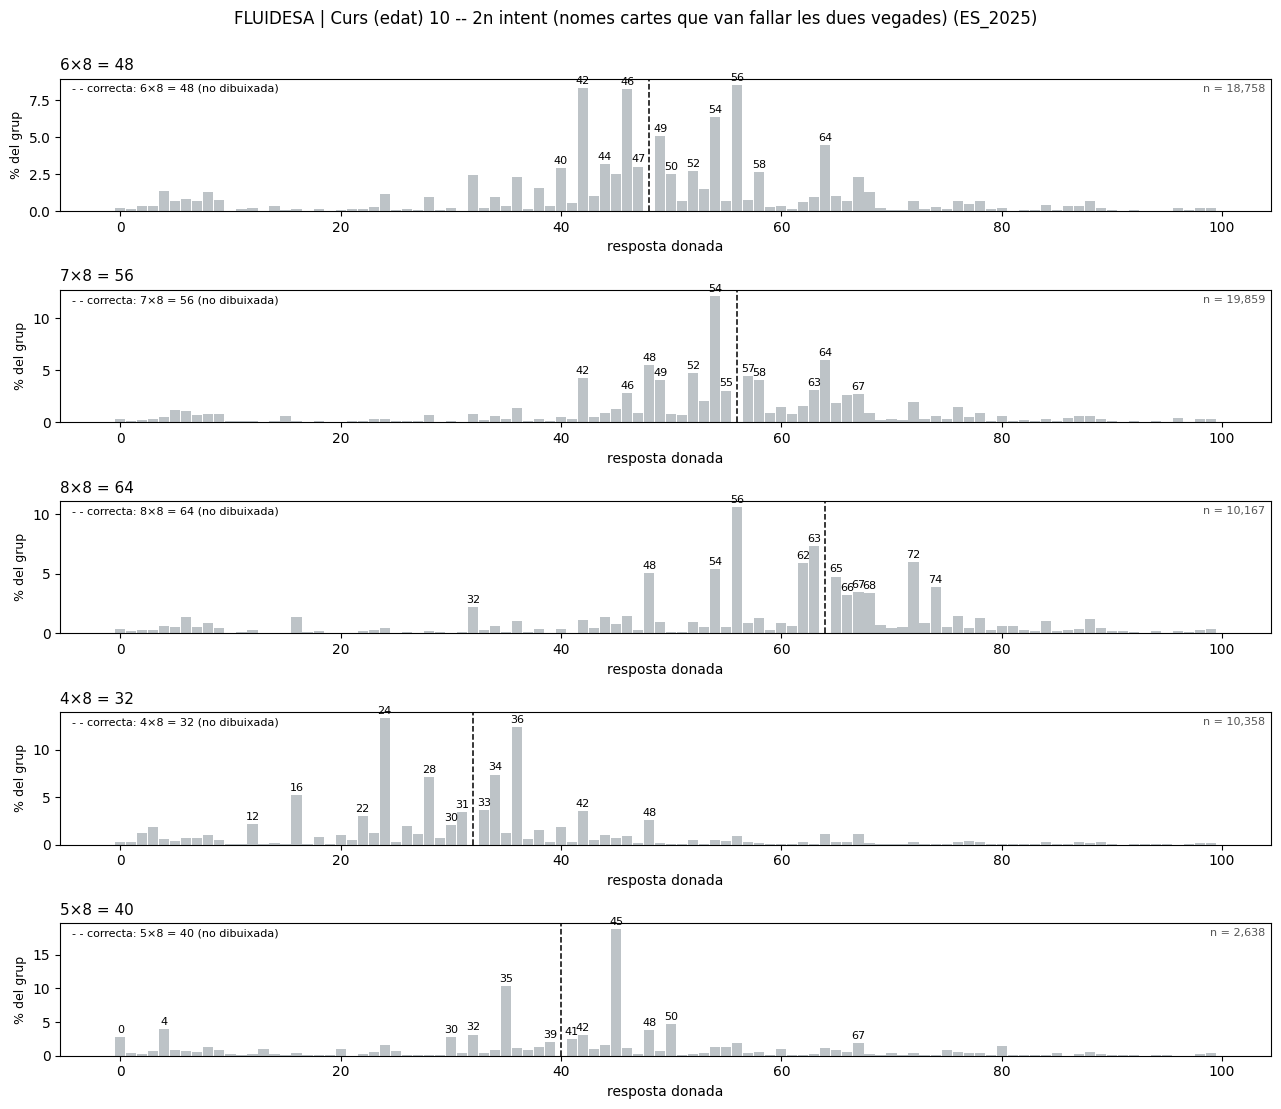

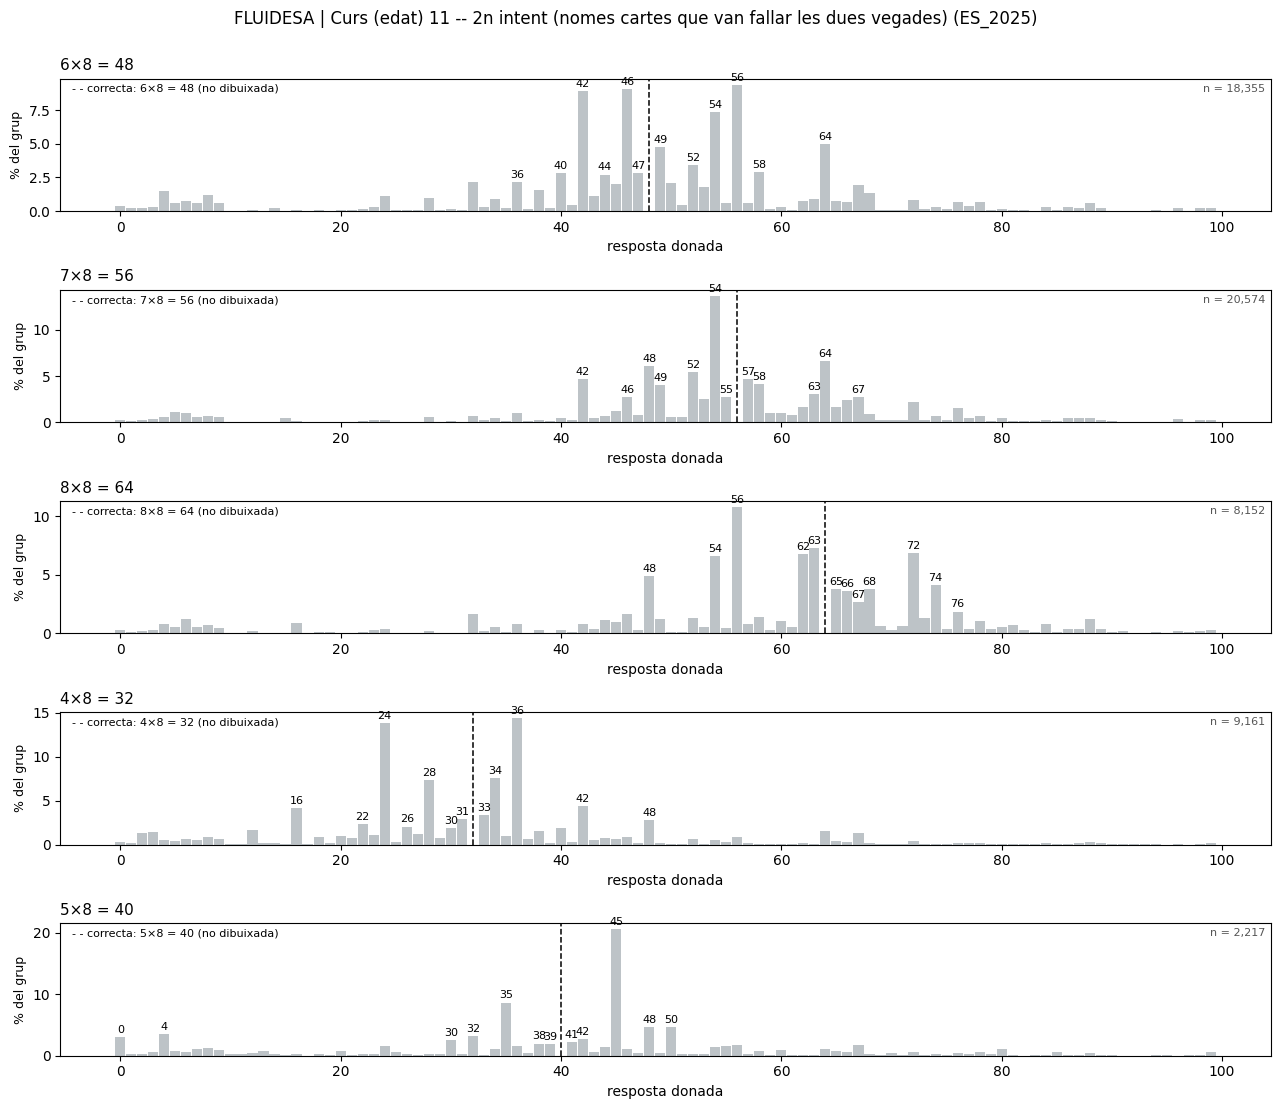

FIG B -> plots/fluency_hardest_errors_attempt2_ageNN.png / .pdf (4 figures)


In [16]:
# --- FIG B: 2n intent ------------------------------------------------------
# Nomes cartes que van acabar 'Incorrect', o sigui que aqui TOTES han fallat els
# dos intents: la divisio de color de la FIG A no te sentit (seria tot gris) i
# es fa servir un sol color. La pregunta d'aquesta figura es si, sabent ja que
# la primera resposta era dolenta, la segona s'acosta a la correcta o no.
for age in AGES:
    plot_attempt(age, 2, split_by_recovery=False)
print(f"FIG B -> plots/fluency_hardest_errors_attempt2_ageNN.png / .pdf ({len(AGES)} figures)")

In [17]:
# --- taules ----------------------------------------------------------------
ORDER = ["neighbour", "off_by_one", "table_multiple", "other_product", "sum",
         "reversed", "fewer_digits", "zero", "other", "too_many_digits",
         "no_answer", "equals_product"]

for att in (1, 2):
    d = err[err["attempt_no"] == att]
    piv = (d.pivot_table(index="error_type", columns="classroom_course_age",
                         values="n", aggfunc="sum", fill_value=0)
            .reindex(ORDER).fillna(0))
    pct = 100 * piv / piv.sum()
    assert np.allclose(pct.sum(), 100), "Les columnes no sumen 100"
    print(f"% de les respostes errronies del intent {att}, per tipus i curs:")
    print(pct.round(2).to_string())
    print()

# Dins de les respostes que es dibuixen (les numeriques de 0 a 99): es la taula
# per interpretar, sense que el 39% de no_answer se n'emporti la massa.
plot_pct = (plot[plot["attempt_no"] == 1]
            .pivot_table(index="error_type", columns="classroom_course_age",
                         values="n", aggfunc="sum", fill_value=0)
            .reindex([t for t in ORDER if t not in NOT_PLOTTED]).fillna(0))
print("% DINS de les respostes numeriques del 1r intent (la taula a interpretar):")
print((100 * plot_pct / plot_pct.sum()).round(2).to_string())

# Recuperacio: quantes de les cartes errades al 1r intent s'arreglen al 2n, i
# depen del tipus d'error? Un veí de taula que es corregeix tot sol es un
# llapsus; si no es corregeix, el fet no hi es.
rec = (err[err["attempt_no"] == 1]
       .groupby("error_type")
       .apply(lambda d: pd.Series({
           "n": d["n"].sum(),
           "pct_recupera_al_2n": 100 * d.loc[d["recovered_at_second"] == 1, "n"].sum()
                                 / d["n"].sum(),
       }), include_groups=False)
       .reindex(ORDER).dropna())
print("\nRecuperacio al 2n intent segons el tipus d'error del 1r:")
print(rec.round(2).to_string())

print("\nPer curs:")
rec_age = (err[err["attempt_no"] == 1]
           .groupby("classroom_course_age")
           .apply(lambda d: pd.Series({
               "n_errats_1r": d["n"].sum(),
               "pct_recupera_al_2n": 100 * d.loc[d["recovered_at_second"] == 1, "n"].sum()
                                     / d["n"].sum(),
           }), include_groups=False))
print(rec_age.round(2).to_string())

# Els pics, amb la durada: es el que deixa veure que aqui NO hi ha dues
# poblacions barrejades com a l'A998.
print("\nTop 8 respostes del 1r intent per operacio (totes les edats):")
top = (plot[plot["attempt_no"] == 1]
       .groupby(["lo", "hi", "product", "user_answer", "error_type"], as_index=False)
       .agg(n=("n", "sum"), med_dur=("median_duration", "median")))
for f in facts.itertuples():
    m = (top["lo"] == f.lo) & (top["hi"] == f.hi)
    d = top[m].nlargest(8, "n").copy()
    d["pct"] = 100 * d["n"] / top.loc[m, "n"].sum()
    print(f"\n  {f.lo}×{f.hi} = {f.product}")
    print(d.astype({"user_answer": int})
           [["user_answer", "error_type", "n", "pct", "med_dur"]]
           .round(2).to_string(index=False))

% de les respostes errronies del intent 1, per tipus i curs:
classroom_course_age     8      9      10     11     12    14
error_type                                                   
neighbour             13.46  18.05  17.35  19.21   0.00   0.0
off_by_one             8.87  10.32   8.91   9.85  21.43   0.0
table_multiple        10.80   7.98   6.54   6.66  14.29  50.0
other_product          6.62   5.13   3.82   3.58   7.14   0.0
sum                    0.94   0.34   0.32   0.25   0.00   0.0
reversed               0.66   0.84   0.83   0.74   0.00   0.0
fewer_digits           6.92   7.80   8.15   7.91   0.00   0.0
zero                   0.17   0.17   0.15   0.14   0.00   0.0
other                 11.77   9.13   7.60   7.80  21.43   0.0
too_many_digits        3.73   3.58   2.82   2.53   0.00   0.0
no_answer             36.05  36.66  43.49  41.33  35.71  50.0
equals_product         0.00   0.00   0.00   0.00   0.00   0.0

% de les respostes errronies del intent 2, per tipus i curs:
classroom

In [18]:
# --- lectura i limits ------------------------------------------------------
n_all = int(err.loc[err["attempt_no"] == 1, "n"].sum())
n_na = int(err[(err["attempt_no"] == 1) & (err["error_type"] == "no_answer")]["n"].sum())
n_plot = int(plot[plot["attempt_no"] == 1]["n"].sum())
pct_rec = 100 * err.loc[(err["attempt_no"] == 1) & (err["recovered_at_second"] == 1), "n"].sum() \
          / n_all

print(">>> LECTURA")
print(f"1) {n_all:,} cartes errades al 1r intent als 5 fets. D'aquestes,")
print(f"   {n_na:,} ({100*n_na/n_all:.1f}%) no tenen cap valor registrat i")
print(f"   {n_plot:,} ({100*n_plot/n_all:.1f}%) son respostes numeriques de 0 a 99")
print("   (la resta: mes xifres que el producte, o marcades errronies amb la")
print("   resposta bona). El % sense resposta es alt i val la pena entendre'l:")
print("   pot ser que deixin la carta a mitges, no que s'equivoquin.")
print(f"2) El {pct_rec:.1f}% de les cartes errades al 1r intent s'encerten al 2n.")
print("   A la FIG A es la part blava de cada barra: els pics enganxats a la")
print("   resposta correcta en tenen molt mes que els llunyans, que es el que")
print("   s'espera si a prop hi ha llapsus i lluny desconeixement.")
print("3) Sense l'artefacte de l'A998, els errors es llegeixen directament i")
print("   surt el mateix patro aritmetic: veins de taula (6x8 -> 42, 54) i")
print("   producte +- 1/2. La confusio d'operacio (suma) i les xifres girades")
print("   son residuals, igual que a l'A998.")
print("4) Un grup que a l'A998 no es podia ni mirar: les respostes amb MENYS")
print("   xifres que el producte. Aqui son el 12,6% i el 63,9% son la desena")
print("   correcta, o sigui alumnes que envien la resposta a mitges. Es un")
print("   comportament d'entrada de dades, no un error de calcul, pero ara es")
print("   pot mesurar perque l'app no els talla.")
print()
print(">>> LIMITS")
print("a) Les taxes d'error NO son comparables amb l'A998 en nivell: alla es un")
print("   test cronometrat de 120 s amb una resposta per item; aqui es practica")
print("   espaiada amb dos intents i sense rellotge. El que es compara es")
print("   QUINES respostes donen, no quantes.")
print("b) Els 5 fets son els de l'A998, no els mes dificils de Fluidesa. A")
print("   Fluidesa manen les taules 11 i 12 (12x12 62,5%), que l'A998 no te.")
print("   4x8 hi es el 13e i 5x8 el 29e -- mira fluency_rank abans de dir")
print("   'aquests son els fets dificils' amb dades d'aquesta app.")
print("c) Fluidesa es un sistema de Leitner: quines cartes veu un alumne depen")
print("   del seu propi historial. Per tant els intents NO son una mostra")
print("   aleatoria de fets ni d'alumnes -- un fet dificil el veuen mes vegades")
print("   els qui el falien. Aixo pot inflar la taxa d'error d'un fet respecte")
print("   d'un test on tothom veu el mateix.")
print("d) El curs surt de d_students.classroom_course_age via student_uuid. La")
print("   mateixa columna que l'A998, pero un altre cami de join -- si algun dia")
print("   la taula de Fluidesa canvia d'identificador, aixo tornaria 0 files")
print("   sense avisar (per aixo el notebook peta si les proves no passen).")
print("e) Res d'aqui es intra-alumne: son marginals de poblacio.")

>>> LECTURA
1) 811,707 cartes errades al 1r intent als 5 fets. D'aquestes,
   318,785 (39.3%) no tenen cap valor registrat i
   467,076 (57.5%) son respostes numeriques de 0 a 99
   (la resta: mes xifres que el producte, o marcades errronies amb la
   resposta bona). El % sense resposta es alt i val la pena entendre'l:
   pot ser que deixin la carta a mitges, no que s'equivoquin.
2) El 58.3% de les cartes errades al 1r intent s'encerten al 2n.
   A la FIG A es la part blava de cada barra: els pics enganxats a la
   resposta correcta en tenen molt mes que els llunyans, que es el que
   s'espera si a prop hi ha llapsus i lluny desconeixement.
3) Sense l'artefacte de l'A998, els errors es llegeixen directament i
   surt el mateix patro aritmetic: veins de taula (6x8 -> 42, 54) i
   producte +- 1/2. La confusio d'operacio (suma) i les xifres girades
   son residuals, igual que a l'A998.
4) Un grup que a l'A998 no es podia ni mirar: les respostes amb MENYS
   xifres que el producte. Aqui so